In [ ]:
from sqlite3 import SQLITE_CREATE_VIEW
import anndata
import scanpy as sc
import os
from bbknn import bbknn
import matplotlib.pyplot as plt
import omicverse as ov
import scvi
import scib
from scvi.model.utils import mde
from scib_metrics.benchmark import Benchmarker
import scanorama
import numpy as np
import pyliger
from harmony import harmonize
from rich import print
import seaborn as sns
import bbknn
import doubletdetection
%matplotlib inline
plt.rcParams.update({'font.size': 12})

In [2]:
# R interface
from rpy2.robjects import pandas2ri
from rpy2.robjects import r
import rpy2.rinterface_lib.callbacks
import anndata2ri

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [ ]:
%%R
# R packages
library(Seurat)

In [ ]:
#####Change path and Load data
os.chdir("/mnt/disk5/Lanxiang/Human_integrated/integrated/8_Progress/monkey_ref_all")
adata = anndata.read_h5ad("monkey_remove_Sasaki.h5ad")

In [ ]:
adata

In [ ]:
adata.obs

In [ ]:
set(adata.obs["harmo.anno"])

In [ ]:
sc.pl.violin(
    adata,
    ["nCount_RNA", "nFeature_RNA", "percent.mt"],
    jitter=0.4,
    multi_panel=True,
    save= "violin_plot.pdf"
)

In [9]:
##filter nFeature_RNA and percent.mt
#adata = adata[adata.obs.nFeature_RNA > 2000, :]
#adata = adata[adata.obs.nCount_RNA > 1000, :]
#adata = adata[adata.obs["percent.mt"] < 15, :]

In [10]:
# remove "empty" genes
sc.pp.filter_genes(adata, min_cells=1)

In [ ]:
adata

In [ ]:
clf = doubletdetection.BoostClassifier(
    n_iters=40,
    clustering_algorithm="louvain",
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=-1,
)
doublets = clf.fit(adata.X).predict(p_thresh=1e-16, voter_thresh=0.5)
doublet_score = clf.doublet_score()

In [13]:
adata.obs["doublet"] = doublets
adata.obs["doublet_score"] = doublet_score

In [ ]:
adata

In [ ]:
print(adata.X)

In [16]:
adata.layers["counts"] = adata.X.copy()

In [17]:
sc.settings.seed = 42
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["logcounts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")
sc.tl.pca(adata, n_comps=30, use_highly_variable=True)

In [ ]:
adata

In [19]:
adata_hvg = adata[:, adata.var.highly_variable].copy()

In [ ]:
adata_hvg

In [ ]:
####Unintegrated
adata.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
adata_hvg.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
sc.pp.neighbors(adata, use_rep="Unintegrated",random_state=42)
sc.tl.leiden(adata, resolution=0.5,key_added=f"Unintegrated_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_Unintegrated'] = adata.obsm['X_umap']
sc.pl.umap(adata, color=['orig.ident'], save="Unintegrated_orig_ident.pdf")
sc.pl.umap(adata, color=['Unintegrated_res_0.5'], save="Unintegrated_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'], save="Unintegrated_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'], save="Unintegrated_harmo.anno.pdf")

In [ ]:
adata

In [ ]:
###Scanorama
import scanorama
batch_cats = adata_hvg.obs['orig.ident'].cat.categories
adata_list = [adata_hvg[adata_hvg.obs['orig.ident'] == b].copy() for b in batch_cats]
scanorama.integrate_scanpy(adata_list)

adata.obsm["Scanorama"] = np.zeros((adata_hvg.shape[0], adata_list[0].obsm["X_scanorama"].shape[1]))
for i, b in enumerate(batch_cats):
    adata.obsm["Scanorama"][adata_hvg.obs['orig.ident'] == b] = adata_list[i].obsm["X_scanorama"]

In [ ]:
adata_hvg.obsm["Scanorama"] = adata.obsm["Scanorama"]
sc.pp.neighbors(adata, use_rep="Scanorama",random_state=42)
sc.tl.leiden(adata, resolution=0.5, key_added=f"Scanorama_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_Scanorama'] = adata.obsm['X_umap']
adata_hvg.obsm['X_Scanorama'] = adata.obsm['X_umap']
sc.pl.umap(adata, color=['orig.ident'], save="Scanorama_orig_ident.pdf")
sc.pl.umap(adata, color=['Scanorama_res_0.5'], save="Scanorama_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'], save="Scanorama_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'], save="Scanorama_harmo.anno.pdf")

In [ ]:
####Liger
bdata = adata_hvg.copy()
# Pyliger normalizes by library size with a size factor of 1
# So here we give it the count data
bdata.X = bdata.layers["counts"]
# List of adata per batch
adata_list = [bdata[bdata.obs['orig.ident'] == b].copy() for b in batch_cats]
for i, ad in enumerate(adata_list):
    ad.uns["sample_name"] = batch_cats[i]
    # Hack to make sure each method uses the same genes
    ad.uns["var_gene_idx"] = np.arange(bdata.n_vars)

liger_data = pyliger.create_liger(adata_list, remove_missing=False, make_sparse=False)
# Hack to make sure each method uses the same genes
liger_data.var_genes = bdata.var_names
pyliger.normalize(liger_data)
pyliger.scale_not_center(liger_data)
pyliger.optimize_ALS(liger_data, k=30)
pyliger.quantile_norm(liger_data)

adata.obsm["LIGER"] = np.zeros((adata_hvg.shape[0], liger_data.adata_list[0].obsm["H_norm"].shape[1]))
for i, b in enumerate(batch_cats):
    adata.obsm["LIGER"][adata_hvg.obs['orig.ident'] == b] = liger_data.adata_list[i].obsm["H_norm"]

In [ ]:
adata_hvg.obsm["LIGER"] = adata.obsm["LIGER"]
sc.pp.neighbors(adata, use_rep="LIGER",random_state=42)
sc.tl.leiden(adata, resolution=0.5, key_added=f"LIGER_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_LIGER'] = adata.obsm['X_umap']
adata_hvg.obsm['X_LIGER'] = adata.obsm['X_LIGER']
sc.pl.umap(adata, color=['orig.ident'],save="Liger_orig.ident.pdf")
sc.pl.umap(adata, color=['LIGER_res_0.5'],save="Liger_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'],save="Liger_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'],save="Liger_harmo.anno.pdf")

In [ ]:
###harmony
adata.obsm["Harmony"] = harmonize(adata_hvg.obsm["X_pca"], adata_hvg.obs, batch_key="orig.ident")

In [ ]:
adata_hvg.obsm["Harmony"] = adata.obsm["Harmony"]
sc.pp.neighbors(adata, use_rep="Harmony",random_state=42)
sc.tl.leiden(adata, resolution=0.5, key_added=f"Harmony_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_Harmony'] = adata.obsm['X_umap']
adata_hvg.obsm['X_Harmony'] = adata.obsm['X_Harmony']
sc.pl.umap(adata, color=['orig.ident'],save="Harmony_orig.ident.pdf")
sc.pl.umap(adata, color=['Harmony_res_0.5'],save="Harmony_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'],save="Harmony_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'],save="Harmony_harmo.anno.pdf")

In [ ]:
print(adata.layers["counts"])

In [ ]:
###scVI
scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="orig.ident")
vae = scvi.model.SCVI(adata_hvg, gene_likelihood="nb", n_layers=2, n_latent=30)
vae.train()
adata.obsm["scVI"] = vae.get_latent_representation()

In [ ]:
adata_hvg.obsm["scVI"] = adata.obsm["scVI"]
sc.pp.neighbors(adata, use_rep="scVI",random_state=42)
sc.tl.leiden(adata, resolution=0.5,key_added=f"scVI_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_scVI'] = adata.obsm['X_umap']
adata_hvg.obsm['X_scVI'] = adata.obsm['X_scVI']
sc.pl.umap(adata, color=['orig.ident'],save="scVI_orig.ident.pdf")
sc.pl.umap(adata, color=['scVI_res_0.5'],save="scVI_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'],save="scVI_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'],save="scVI_harmo.anno.pdf")

In [ ]:
###scANVI
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata_hvg,
    labels_key="harmo.anno",
    unlabeled_category="Unknown",
)
lvae.train(max_epochs=20, n_samples_per_label=100)
adata.obsm["scANVI"] = lvae.get_latent_representation()

In [ ]:
adata_hvg.obsm["scANVI"] = adata.obsm["scANVI"]
sc.pp.neighbors(adata, use_rep="scANVI",random_state=42)
sc.tl.leiden(adata, resolution=0.5,key_added=f"scANVI_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_scANVI'] = adata.obsm['X_umap']
adata_hvg.obsm['X_scANVI'] = adata.obsm['X_scANVI']
sc.pl.umap(adata, color=['orig.ident'],save="scANVI_orig.ident.pdf")
sc.pl.umap(adata, color=['scANVI_res_0.5'],save="scANVI_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'],save="scANVI_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'],save="scANVI_harmo.anno.pdf")

In [ ]:
####CCA
adata_seurat = adata_hvg.copy()

adata_seurat.obs["orig.ident"] = adata_seurat.obs["orig.ident"].astype(str)
adata_seurat.obs["harmo.anno"] = adata_seurat.obs["harmo.anno"].astype(str)

del adata_seurat.uns
adata_seurat

In [ ]:
#####to R
%R -i adata_seurat
adata_seurat

In [ ]:
%%R -i adata_seurat
library(Seurat)
seurat <- as.Seurat(adata_seurat, counts = "counts", data = "logcounts")
seurat

In [37]:
label_key = "harmo.anno"
batch_key = "orig.ident"

In [ ]:
%%R -i batch_key
batch_list <- SplitObject(seurat, split.by = "orig.ident")
batch_list

In [ ]:
%%R
anchors <- FindIntegrationAnchors(batch_list, anchor.features = rownames(seurat))
anchors

In [ ]:
%%R
integrated <- IntegrateData(anchors)
integrated

In [ ]:
%%R
integrated

In [ ]:
%%R -o integrated_expr
integrated_expr <- GetAssayData(integrated)

integrated_expr <- integrated_expr[rownames(seurat), colnames(seurat)]

integrated_expr <- t(integrated_expr)
print(integrated_expr[1:10, 1:10])

In [ ]:
## save to adata key
adata_seurat.X = integrated_expr
adata_seurat.layers["seurat"] = integrated_expr
print(adata_seurat)
adata.X

In [44]:
sc.tl.pca(adata_seurat)
adata.obsm["CCA"] = adata_seurat.obsm["X_pca"]
adata_hvg.obsm["CCA"] = adata_seurat.obsm["X_pca"]

In [ ]:
sc.pp.neighbors(adata, use_rep="CCA",random_state=42)
sc.tl.leiden(adata, resolution=0.5, key_added=f"CCA_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_CCA'] = adata.obsm['X_umap']
adata_hvg.obsm['X_CCA'] = adata.obsm['X_CCA']
sc.pl.umap(adata, color=['orig.ident'],save="CCA_orig.ident.pdf")
sc.pl.umap(adata, color=['CCA_res_0.5'],save="CCA_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'],save="CCA_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'],save="CCA_harmo.anno.pdf")

In [ ]:
###fastmnn
adata_fastmnn = adata_hvg.copy()
adata_fastmnn

In [ ]:
adata_fastmnn.obs["orig.ident"] = adata_fastmnn.obs["orig.ident"].astype(str)
adata_fastmnn.obs["harmo.anno"] = adata_fastmnn.obs["harmo.anno"].astype(str)

del adata_fastmnn.uns
adata_fastmnn

In [ ]:
#####to R
%R -i adata_fastmnn
adata_fastmnn

In [ ]:
%%R -i adata_fastmnn
library(Seurat)
fastmnn <- as.Seurat(adata_fastmnn, counts = "counts", data = "logcounts")
fastmnn

In [50]:
label_key = "harmo.anno"
batch_key = "orig.ident"

In [ ]:
%%R -i batch_key
batch_list <- SplitObject(fastmnn, split.by = "orig.ident")
batch_list

In [ ]:
%%R
library(Seurat)
library(tidyverse)
library(patchwork)
library(SeuratWrappers)
fastmnn_test <- RunFastMNN(object.list = batch_list)
fastmnn_test

In [ ]:
%%R
fastmnn_test

In [ ]:
%%R -o fastmnn_expr
fastmnn_expr <- GetAssayData(fastmnn_test, assay = "mnn.reconstructed")

fastmnn_expr <- fastmnn_expr[rownames(fastmnn), colnames(fastmnn)]

fastmnn_expr <- t(fastmnn_expr)
print(fastmnn_expr[1:10, 1:10])

In [ ]:
## save to adata key
adata_fastmnn.X = fastmnn_expr
adata_fastmnn.layers["fastmnn"] = fastmnn_expr
print(adata_fastmnn)
adata.X

In [56]:
sc.tl.pca(adata_fastmnn)
adata.obsm["FastMNN"] = adata_fastmnn.obsm["X_pca"]
adata_hvg.obsm["FastMNN"] = adata_fastmnn.obsm["X_pca"]

In [ ]:
sc.pp.neighbors(adata, use_rep="FastMNN",random_state=42)
sc.tl.leiden(adata, resolution=0.5, key_added=f"FastMNN_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_FastMNN'] = adata.obsm['X_umap']
adata_hvg.obsm['X_FastMNN'] = adata.obsm['X_FastMNN']
sc.pl.umap(adata, color=['orig.ident'],save="FastMNN_orig.ident.pdf")
sc.pl.umap(adata, color=['FastMNN_res_0.5'],save="FastMNN_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'],save="FastMNN_stage.pdf")
sc.pl.umap(adata, color=['harmo.anno'],save="FastMNN_harmo.anno.pdf")

In [ ]:
adata

In [ ]:
print(adata.layers["counts"])

In [ ]:
####Perform the benchmark
bm = Benchmarker(
    adata,
    batch_key="orig.ident",
    label_key="harmo.anno",
    embedding_obsm_keys=["Unintegrated", "Scanorama", "LIGER", "Harmony", "scVI", "scANVI","CCA","FastMNN"],
    n_jobs=6,
)
bm.benchmark()

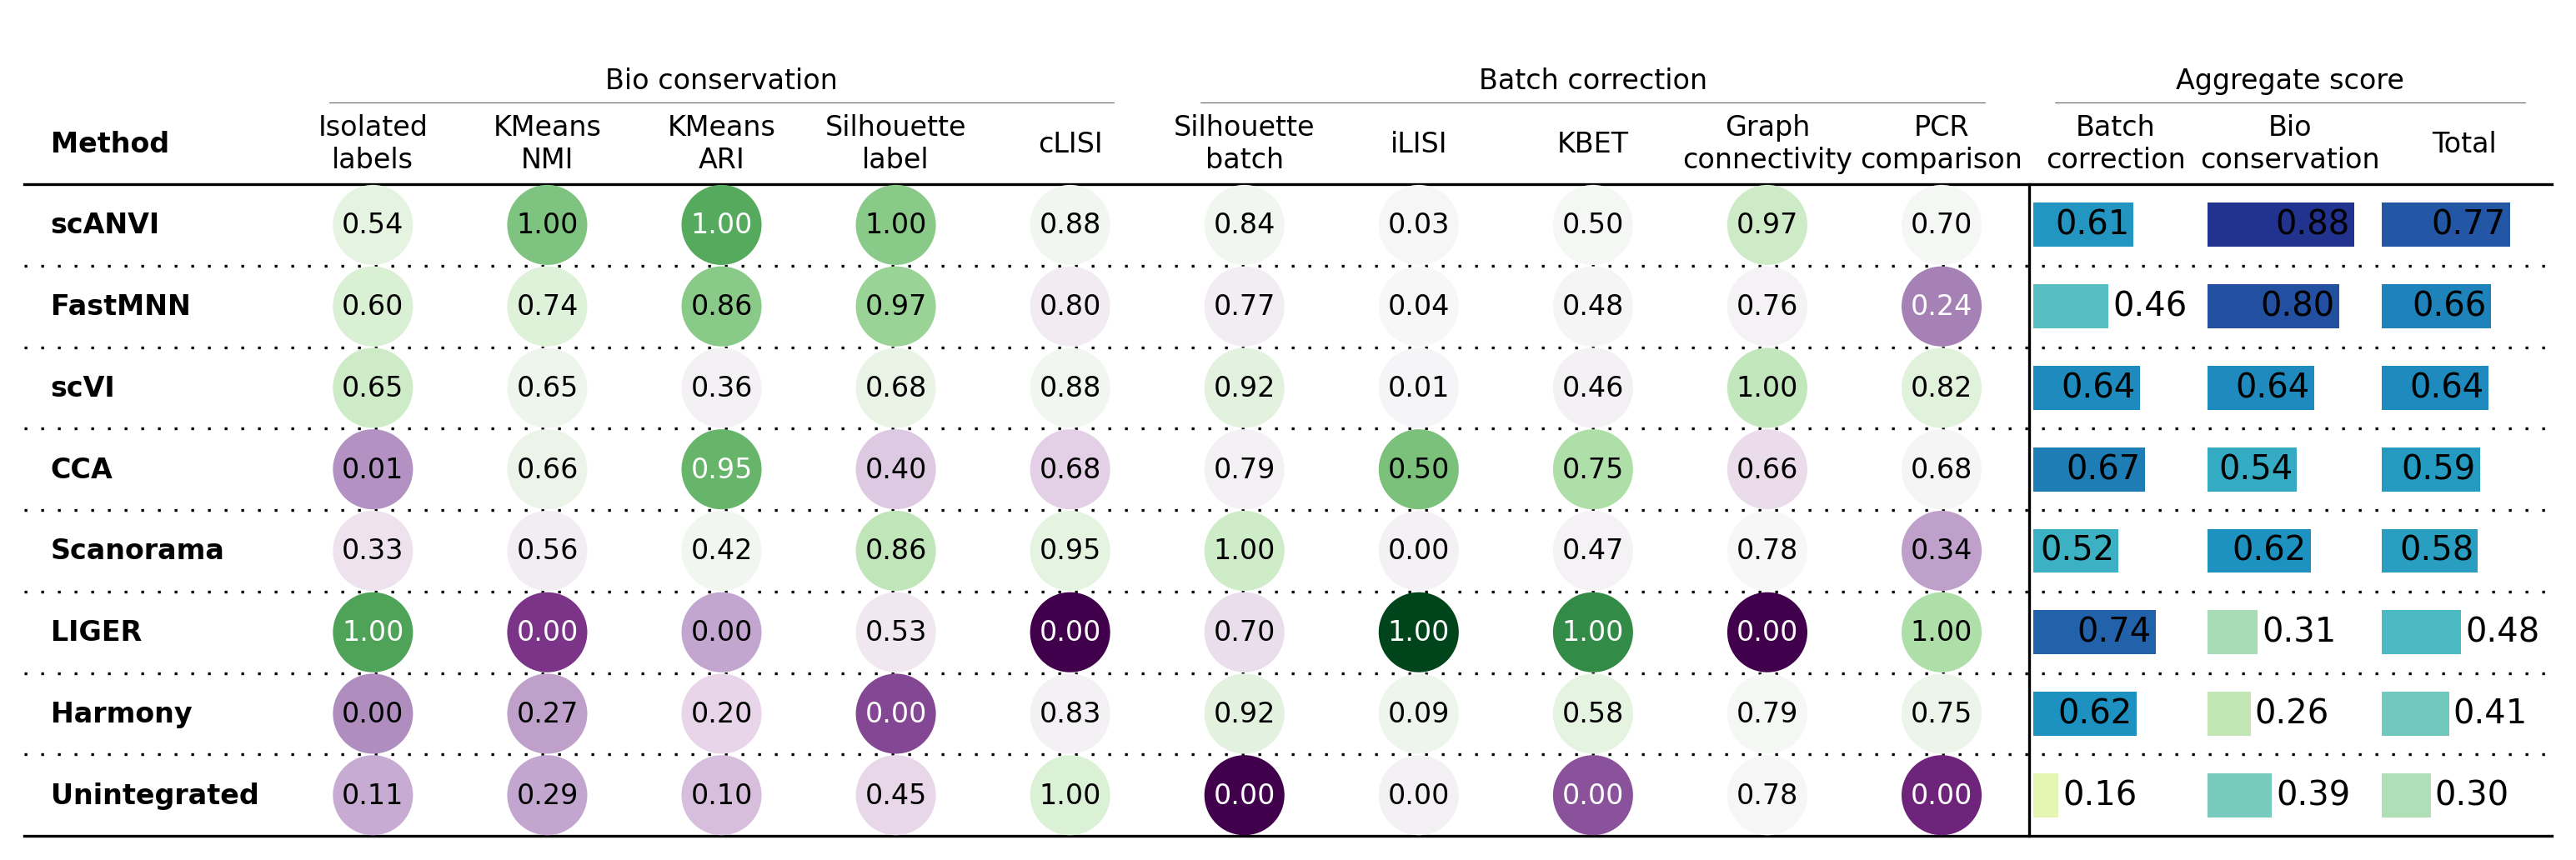

In [61]:
bm.plot_results_table(save_dir="/mnt/disk5/Lanxiang/Human_integrated/integrated/8_Progress/monkey_ref_all/figures")

In [ ]:
from rich import print

df2 = bm.get_results()
print(df2)

In [ ]:
df2.transpose()

In [71]:
df2_transposed = df2.transpose()
df2_transposed.to_csv('scib_df_transposed_min_max_scale=True.csv', index=False)

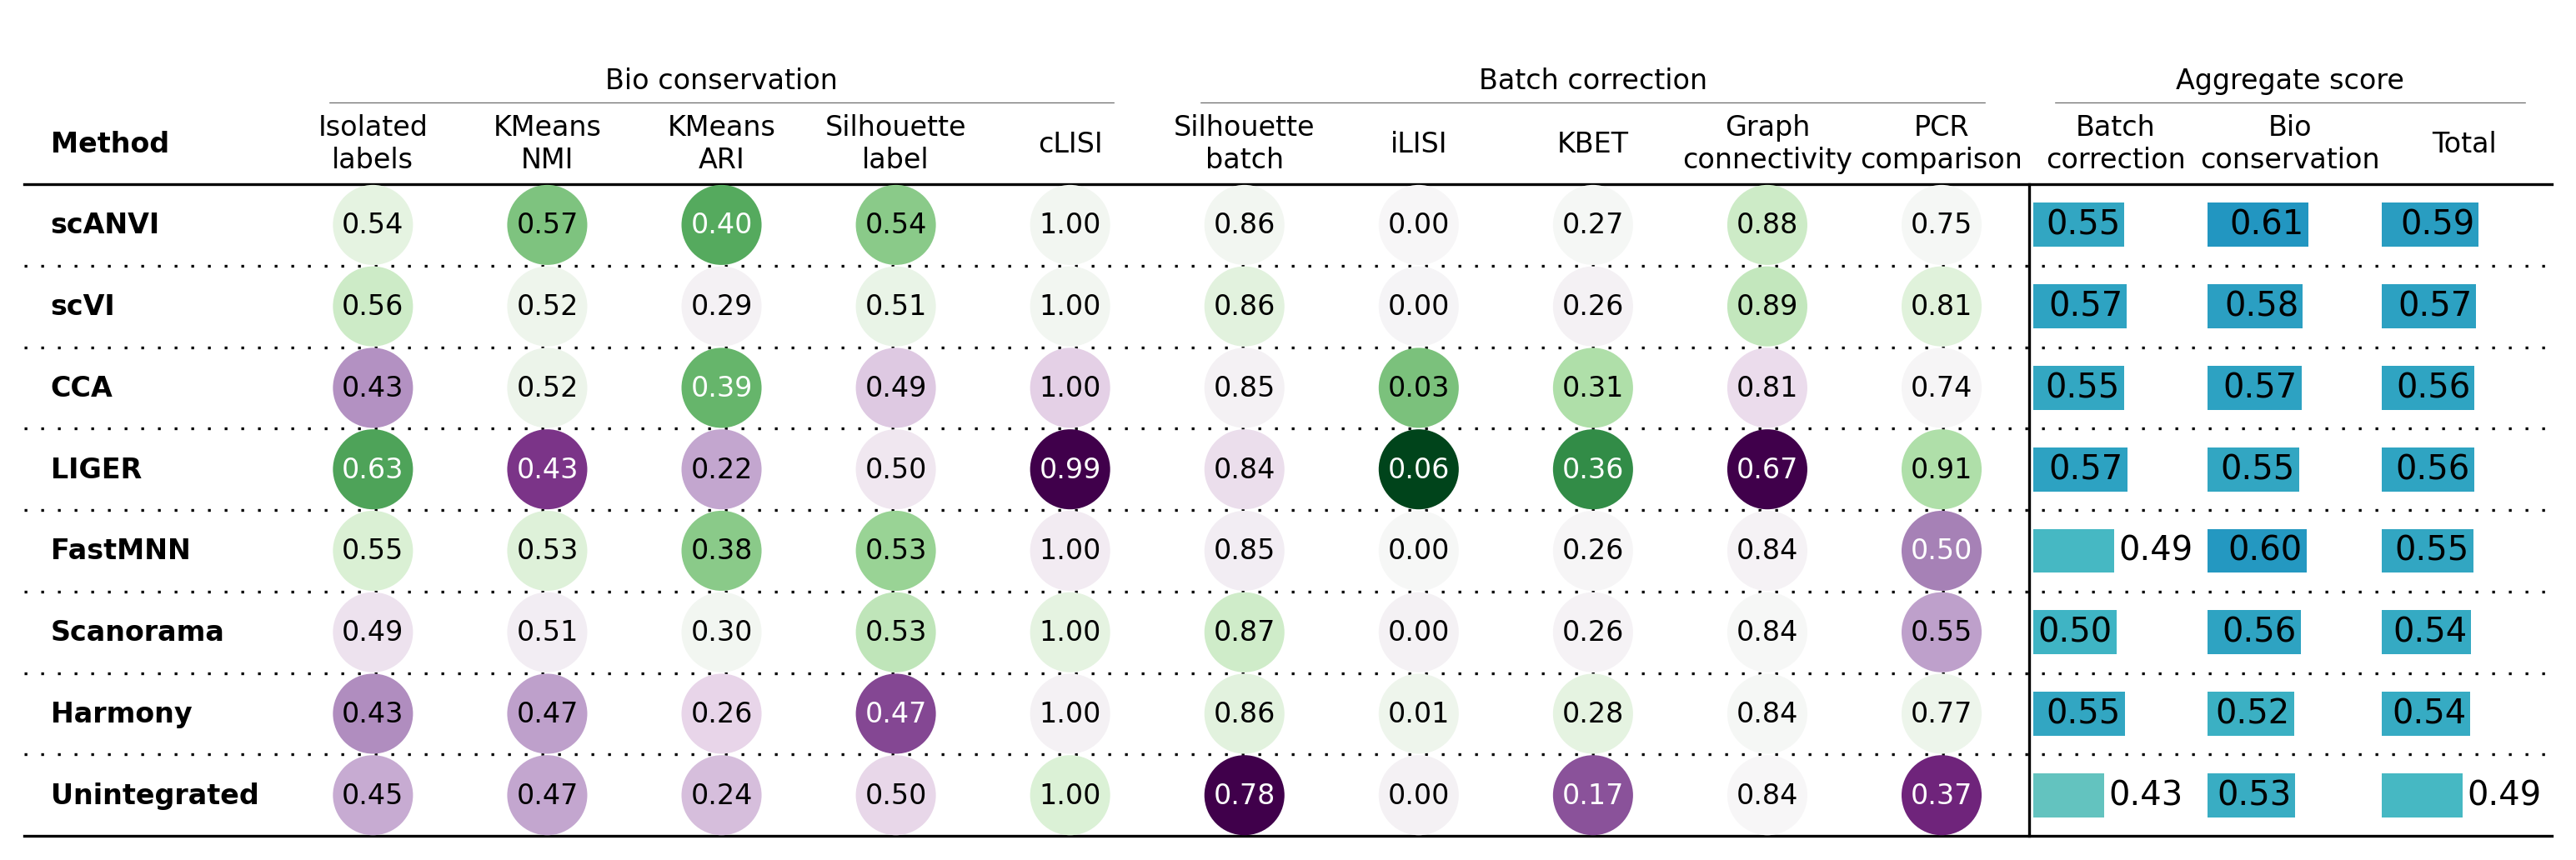

In [62]:
bm.plot_results_table(min_max_scale=False,save_dir="/mnt/disk5/Lanxiang/Human_integrated/integrated/8_Progress/monkey_ref_all/figures/")

In [63]:
adata.raw.var.rename(columns={'_index': 'index'}, inplace=True)
adata.write_h5ad(filename="scib_monkey_remove_Sasaki8.20.h5ad")

In [ ]:
from rich import print

df = bm.get_results(min_max_scale=False)
print(df)

In [68]:
df.to_csv('scib_df.csv')

In [ ]:
df.transpose()

In [67]:
df_transposed = df.transpose()
df_transposed.to_csv('scib_df_transposed.csv', index=False)